# Dataset tests

Run one 32-token prompt from a text dataset through a single model using the analyzer pipeline. If needed, swap `DatasetPromptSource` for `RandomTokenPromptSource` without changing the rest of the code.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM


def compute_cosine_sim_distribution(
    model_name: str = "Qwen/Qwen2.5-0.5B-Instruct",
    chunk_size: int = 512,
    n_bins: int = 200,
):
    """
    Computes the full pairwise cosine similarity distribution over all tokens
    without materializing the V×V matrix.

    Strategy: stream rows in chunks of `chunk_size`, accumulate a histogram
    bin-by-bin instead of storing individual values.

    Memory peak: chunk_size × V × 4 bytes
      e.g. chunk=512, V=151k → ~310 MB peak, regardless of V.
    """
    print(f"[Info] Loading model: {model_name}")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cpu",
        trust_remote_code=True,
        torch_dtype=torch.float32,
    )

    if hasattr(model, "model") and hasattr(model.model, "embed_tokens"):
        E = model.model.embed_tokens.weight.detach()
    else:
        E = model.get_input_embeddings().weight.detach()

    V, d = E.shape
    print(f"[Info] Embedding matrix: {V} tokens × {d} dimensions")

    # -----------------------------------------------------------------------
    # Step 1: Normalize all embeddings to unit length — O(V × d), fine.
    # -----------------------------------------------------------------------
    norms = torch.norm(E, dim=1, keepdim=True).clamp(min=1e-8)
    E_hat = E / norms  # (V, d)

    # -----------------------------------------------------------------------
    # Step 2: Exact mean via the algebraic identity — O(d), negligible.
    # -----------------------------------------------------------------------
    mean_vec = E_hat.sum(dim=0)               # (d,)
    sum_of_sq = mean_vec.dot(mean_vec).item() # ||Σ ê_i||²
    exact_mean = (sum_of_sq - V) / (V * (V - 1))
    print(f"[Info] Exact mean cosine similarity (all pairs): {exact_mean:.6f}")

    # -----------------------------------------------------------------------
    # Step 3: Histogram via row-chunk streaming.
    # For chunk rows i, compute sim(i, j) for all j > i (upper triangle only).
    # Accumulate into a fixed-size histogram to avoid storing V² values.
    # -----------------------------------------------------------------------
    bin_edges = np.linspace(-1.0, 1.0, n_bins + 1)
    histogram  = np.zeros(n_bins, dtype=np.float64)

    n_chunks = (V + chunk_size - 1) // chunk_size
    total_pairs = V * (V - 1) // 2
    processed_pairs = 0

    print(f"[Info] Streaming {n_chunks} chunks of {chunk_size} rows...")
    for chunk_start in range(0, V, chunk_size):
        chunk_end = min(chunk_start + chunk_size, V)
        chunk = E_hat[chunk_start:chunk_end]  # (chunk, d)

        # Similarity of this chunk against all tokens with index > chunk
        # We only compute upper-triangle to avoid double counting.
        # sim_block[i, j] = cos(chunk_start+i, j) for j > chunk_start+i
        sim_block = chunk @ E_hat.T            # (chunk, V)

        for local_i, global_i in enumerate(range(chunk_start, chunk_end)):
            # Upper-triangle: only j > global_i
            row = sim_block[local_i, global_i + 1:]   # (V - global_i - 1,)
            if row.numel() == 0:
                continue
            counts, _ = np.histogram(row.numpy(), bins=bin_edges)
            histogram += counts
            processed_pairs += row.numel()

        pct = 100 * processed_pairs / total_pairs
        print(f"\r  Progress: {pct:.1f}%  ({processed_pairs:,} / {total_pairs:,} pairs)", end="")

    print(f"\n[Info] Total pairs processed: {processed_pairs:,}")

    # -----------------------------------------------------------------------
    # Step 4: Plot — log-scale y axis
    # -----------------------------------------------------------------------
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    density = histogram / (histogram.sum() * (bin_edges[1] - bin_edges[0]))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(bin_centers, density, width=bin_edges[1] - bin_edges[0],
           color="teal", alpha=0.75, label="Empirical density")
    ax.axvline(exact_mean, color="crimson", linestyle="--", linewidth=1.8,
               label=f"Mean = {exact_mean:.4f}")
    ax.set_yscale("log")
    ax.set_xlabel("Pairwise Cosine Similarity", fontsize=12)
    ax.set_ylabel("Density (log scale)", fontsize=12)
    ax.set_title(
        f"Token Embedding Cosine Similarity — {model_name}\n"
        f"V = {V}, d = {d}, pairs = {total_pairs:,}",
        fontsize=11,
    )
    ax.legend()
    plt.tight_layout()
    plt.savefig("cosine_sim_distribution.png", dpi=300)
    print("[Info] Saved → cosine_sim_distribution.png")

    return {
        "exact_mean_cosine_sim": exact_mean,
        "total_pairs": total_pairs,
        "histogram": histogram,
        "bin_edges": bin_edges,
    }

compute_cosine_sim_distribution("Qwen/Qwen3-4B", chunk_size=512)

/Users/raffaeledagostino/anaconda3/envs/master_thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Info] Loading model: Qwen/Qwen3-4B


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights:  30%|███       | 121/398 [00:18<00:42,  6.59it/s, Materializing param=model.layers.10.self_attn.q_proj.weight]        


KeyboardInterrupt: 

In [ ]:
import pandas as pd


df = pd.read_parquet('Mistral_512tok.parquet')
#df = pd.read_parquet('Qwen3_4B_512tok.parquet')
#df = pd.read_parquet('Mistral_512tok_fix.parquet')


In [40]:
df.head()

model_name  \
run_idx                                            sub_idx                                       
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0        mistralai/Mistral-7B-Instruct-v0.3   
                                                   1        mistralai/Mistral-7B-Instruct-v0.3   
                                                   2        mistralai/Mistral-7B-Instruct-v0.3   
                                                   3        mistralai/Mistral-7B-Instruct-v0.3   
                                                   4        mistralai/Mistral-7B-Instruct-v0.3   

                                                            layer_idx  \
run_idx                                            sub_idx              
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0                0   
                                                   1                0   
                                                   2                0   
                                                   3                0   
                                                   4                0   

                                                            head_idx  \
run_idx                                            sub_idx             
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0               0   
                                                   1               1   
                                                   2               2   
                                                   3               3   
                                                   4               4   

                                                            prompt_len  \
run_idx                                            sub_idx               
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0               512   
                                                   1               512   
                                                   2               512   
                                                   3               512   
                                                   4               512   

                                                                                 prompt_source  \
run_idx                                            sub_idx                                       
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0        wikitext_wikitext-103-raw-v1_train   
                                                   1        wikitext_wikitext-103-raw-v1_train   
                                                   2        wikitext_wikitext-103-raw-v1_train   
                                                   3        wikitext_wikitext-103-raw-v1_train   
                                                   4        wikitext_wikitext-103-raw-v1_train   

                                                            effective_rank_Wq  \
run_idx                                            sub_idx                      
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0               419.095886   
                                                   1               419.095886   
                                                   2               419.095886   
                                                   3               419.095886   
                                                   4               419.095886   

                                                            r95_Wq  \
run_idx                                            sub_idx           
mistralai/Mistral-7B-Instruct-v0.3::wikitext_wi... 0        1109.0   
                                                   1        1109.0   
                                                   2        1109.0   
                                                   3        1109.0   
                                                   4        1109.0   

                                                            effective_rank_Wk  \
run_idx                           

In [34]:
# Focused EDA: correlations + WqRWk alignment heatmaps (from FEATURE_REGISTRY)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from core.features_library import FEATURE_REGISTRY
pio.renderers.default = "vscode"

sources = sorted(df["prompt_source"].dropna().astype(str).unique().tolist())
print("Prompt sources:", sources)

META_COLS = {"model_name", "prompt_id", "prompt_source", "layer_idx", "head_idx", "run_idx"}

# All numeric features in the dataset (not only registry columns).
all_numeric_features = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in META_COLS
]

registry_features = list(FEATURE_REGISTRY.keys())
available_registry_features = [f for f in registry_features if f in df.columns]
print(f"Registry features found in df: {len(available_registry_features)}/{len(registry_features)}")
print(f"Total numeric features used for correlation: {len(all_numeric_features)}")

# Canonical feature groups from features_library naming.
model_dependent_features = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "rmsnorm_gamma_norm",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_norm_Wq", "rope_pair_max_norm_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
    "compute_WqRWk_alignment_delta_1",
    "compute_WqRWk_alignment_delta_2",
    "compute_WqRWk_alignment_delta_3",
    "compute_WqRWk_alignment_delta_4",
]

input_dependent_features = [
    "effective_rank_H", "r95_H",
    "effective_rank_Q", "r95_Q",
    "effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    "svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]

model_set = set(model_dependent_features)
input_set = set(input_dependent_features)
target_set = set(target_features)

def classify_feature(name):
    if name in model_set:
        return "model"
    if name in input_set:
        return "input"
    if name in target_set:
        return "target"

    n = name.lower()
    if any(k in n for k in ["wq", "wk", "wv", "weight", "rope", "rmsnorm", "gamma"]):
        return "model"
    if any(k in n for k in ["_h", "_q", "_k", "q_sim", "k_sim", "svd_alignment_h"]):
        return "input"
    return "target"

def ordered_group(features, canonical_order):
    present = [f for f in canonical_order if f in features]
    rest = sorted([f for f in features if f not in set(canonical_order)], key=str.lower)
    return present + rest

model_group = [f for f in all_numeric_features if classify_feature(f) == "model"]
input_group = [f for f in all_numeric_features if classify_feature(f) == "input"]
target_group = [f for f in all_numeric_features if classify_feature(f) == "target"]

model_group = ordered_group(model_group, model_dependent_features)
input_group = ordered_group(input_group, input_dependent_features)
target_group = ordered_group(target_group, target_features)

sorted_features = model_group + input_group + target_group

print("Feature ordering for correlation:")
print("  model-dependent:", len(model_group))
print("  input-dependent:", len(input_group))
print("  target:", len(target_group))

# Boundaries used to draw dividers between the three blocks.
b1 = len(model_group)
b2 = len(model_group) + len(input_group)
boundaries = [b for b in [b1, b2] if 0 < b < len(sorted_features)]

def add_group_dividers(fig, n_features, boundaries):
    for b in boundaries:
        pos = b - 0.5
        fig.add_shape(
            type="line",
            x0=pos, x1=pos, y0=-0.5, y1=n_features - 0.5,
            line=dict(color="black", width=2),
        )
        fig.add_shape(
            type="line",
            x0=-0.5, x1=n_features - 0.5, y0=pos, y1=pos,
            line=dict(color="black", width=2),
        )

def find_source(keyword, fallback_index=None):
    matches = [s for s in sources if keyword in s.lower()]
    if matches:
        return matches[0]
    if fallback_index is not None and fallback_index < len(sources):
        return sources[fallback_index]
    return None

random_source = find_source("random", fallback_index=0)
wikitext_source = find_source("wiki", fallback_index=1 if len(sources) > 1 else 0)

for label, src in [("Random dataset", random_source), ("WikiText dataset", wikitext_source)]:
    if src is None:
        print(f"[Skip] {label}: source not found in prompt_source column.")
        continue

    sub = df[df["prompt_source"] == src]
    if sub.empty:
        print(f"[Skip] {label}: no rows for source={src}.")
        continue

    corr = sub[sorted_features].corr()
    fig = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        title=f"<b>Correlation Matrix</b> — {label} ({src})",
        labels={"x": "Feature", "y": "Feature", "color": "Correlation"},
    )
    fig.update_xaxes(tickangle=-45)
    add_group_dividers(fig, n_features=len(sorted_features), boundaries=boundaries)
    fig.update_layout(width=1000, height=900)
    fig.show()

# Exact WqRWk alignment feature names from FEATURE_REGISTRY.
wqrwk_alignment_feats = [
    f for f in available_registry_features if f.startswith("compute_WqRWk_alignment_delta_")
]

# Enforce delta order 0..4.
wqrwk_alignment_feats = sorted(wqrwk_alignment_feats, key=lambda s: int(s.rsplit("_", 1)[-1]))

if not wqrwk_alignment_feats:
    print("[Skip] No compute_WqRWk_alignment_delta_* columns found.")
else:
    print("WqRWk alignment features:", wqrwk_alignment_feats)

for feat in wqrwk_alignment_feats:
    fig = make_subplots(
        rows=1,
        cols=max(1, len(sources)),
        subplot_titles=[f"{s} (n={int((df['prompt_source'] == s).sum())})" for s in sources],
        shared_yaxes=True,
    )

    global_vals = df[feat].dropna()
    zmin = float(global_vals.min()) if not global_vals.empty else None
    zmax = float(global_vals.max()) if not global_vals.empty else None

    for col_idx, src in enumerate(sources, start=1):
        sub = df[df["prompt_source"] == src]
        agg = (
            sub.groupby(["head_idx", "layer_idx"], as_index=False)[feat]
            .mean()
            .sort_values(["head_idx", "layer_idx"])
)

        pivot = agg.pivot(index="head_idx", columns="layer_idx", values=feat)
        pivot = pivot.sort_index().sort_index(axis=1)

        fig.add_trace(
            go.Heatmap(
                z=pivot.values,
                x=pivot.columns,
                y=pivot.index,
                coloraxis="coloraxis",
                hovertemplate="Layer=%{x}<br>Head=%{y}<br>value=%{z:.4f}<extra></extra>",
            ),
            row=1,
            col=col_idx,
        )

        fig.update_xaxes(title_text="Layer", row=1, col=col_idx)
        fig.update_yaxes(title_text="Head", row=1, col=col_idx)

    fig.update_layout(
        title=f"<b>{feat}</b> — layer x head heatmap by prompt type (mean over prompts)",
        coloraxis=dict(colorscale="Viridis", cmin=zmin, cmax=zmax, colorbar_title=feat),
        width=max(520 * max(1, len(sources)), 950),
        height=500,
)
    fig.show()

Prompt sources: ['random_vocab', 'wikitext_wikitext-103-raw-v1_train']
Registry features found in df: 48/48
Total numeric features used for correlation: 49
Feature ordering for correlation:
  model-dependent: 20
  input-dependent: 10
  target: 19


WqRWk alignment features: ['compute_WqRWk_alignment_delta_0', 'compute_WqRWk_alignment_delta_1', 'compute_WqRWk_alignment_delta_2', 'compute_WqRWk_alignment_delta_3', 'compute_WqRWk_alignment_delta_4']


# Rank W_q W_k W_v correlations

Generating Q vs K effective ranks plot...
Generating Q vs K R95 plot...
Generating V vs K effective ranks plot...
Generating V vs K R95 plot...
Generating Q vs V effective ranks plot...
Generating Q vs V R95 plot...
Generating effective ranks distribution plot...
Generating R95 distribution plot...


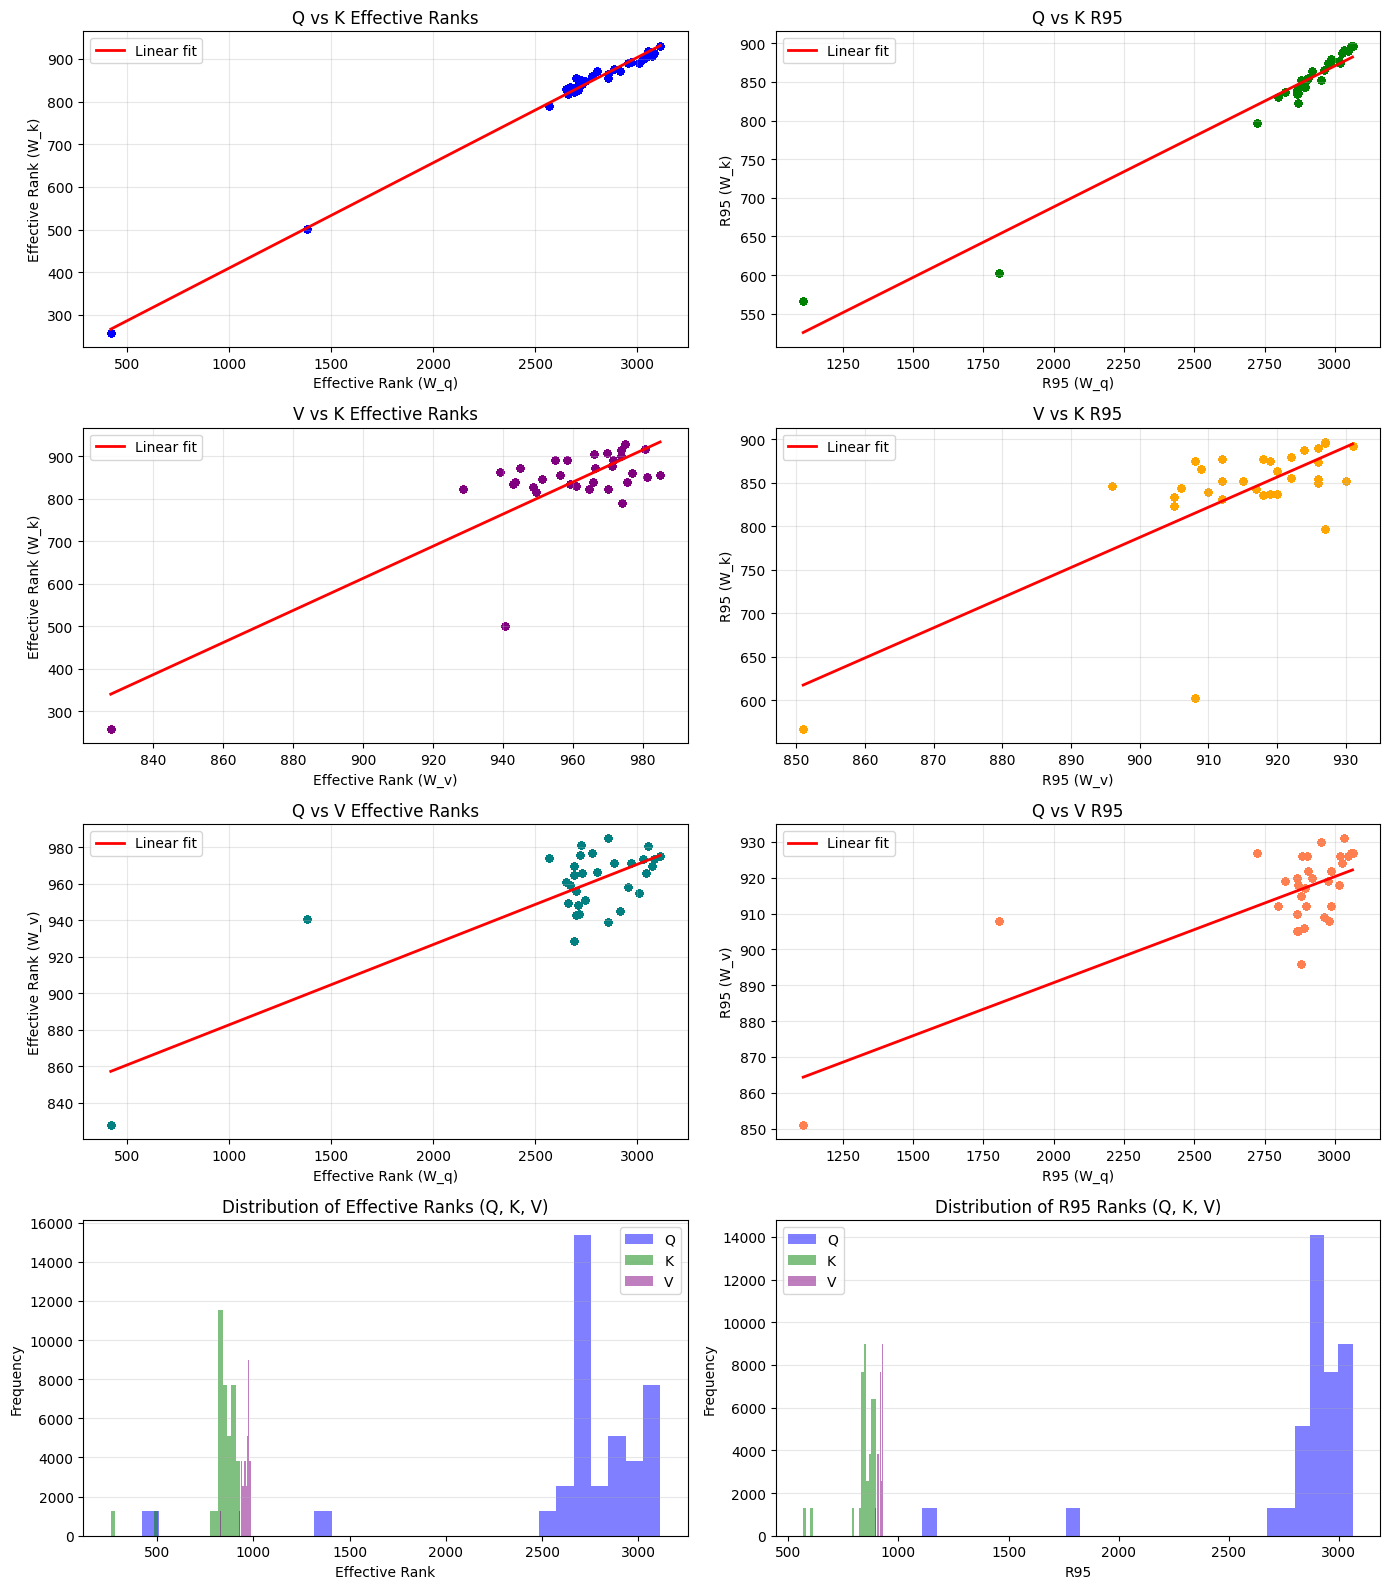

All rank analysis plots generated successfully!


In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ==================== RANK ANALYSIS PLOTS ====================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# 1. Q vs K Effective Ranks with interpolation
print("Generating Q vs K effective ranks plot...")
q_erank = df['effective_rank_Wq'].values
k_erank = df['effective_rank_Wk'].values

mask = ~(np.isnan(q_erank) | np.isnan(k_erank))
q_erank_clean = q_erank[mask]
k_erank_clean = k_erank[mask]

z = np.polyfit(q_erank_clean, k_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_erank_clean.min(), q_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[0, 0].scatter(q_erank_clean, k_erank_clean, alpha=0.5, s=20, color='blue')
axes[0, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[0, 0].set_xlabel('Effective Rank (W_q)')
axes[0, 0].set_ylabel('Effective Rank (W_k)')
axes[0, 0].set_title('Q vs K Effective Ranks')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q vs K R95 with interpolation
print("Generating Q vs K R95 plot...")
q_r95 = df['r95_Wq'].values
k_r95 = df['r95_Wk'].values

mask = ~(np.isnan(q_r95) | np.isnan(k_r95))
q_r95_clean = q_r95[mask]
k_r95_clean = k_r95[mask]

z = np.polyfit(q_r95_clean, k_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_r95_clean.min(), q_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[0, 1].scatter(q_r95_clean, k_r95_clean, alpha=0.5, s=20, color='green')
axes[0, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[0, 1].set_xlabel('R95 (W_q)')
axes[0, 1].set_ylabel('R95 (W_k)')
axes[0, 1].set_title('Q vs K R95')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. V vs K Effective Ranks with interpolation
print("Generating V vs K effective ranks plot...")
v_erank = df['effective_rank_Wv'].values
k_erank = df['effective_rank_Wk'].values

mask = ~(np.isnan(v_erank) | np.isnan(k_erank))
v_erank_clean = v_erank[mask]
k_erank_clean = k_erank[mask]

z = np.polyfit(v_erank_clean, k_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(v_erank_clean.min(), v_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[1, 0].scatter(v_erank_clean, k_erank_clean, alpha=0.5, s=20, color='purple')
axes[1, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[1, 0].set_xlabel('Effective Rank (W_v)')
axes[1, 0].set_ylabel('Effective Rank (W_k)')
axes[1, 0].set_title('V vs K Effective Ranks')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. V vs K R95 with interpolation
print("Generating V vs K R95 plot...")
v_r95 = df['r95_Wv'].values
k_r95 = df['r95_Wk'].values

mask = ~(np.isnan(v_r95) | np.isnan(k_r95))
v_r95_clean = v_r95[mask]
k_r95_clean = k_r95[mask]

z = np.polyfit(v_r95_clean, k_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(v_r95_clean.min(), v_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[1, 1].scatter(v_r95_clean, k_r95_clean, alpha=0.5, s=20, color='orange')
axes[1, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[1, 1].set_xlabel('R95 (W_v)')
axes[1, 1].set_ylabel('R95 (W_k)')
axes[1, 1].set_title('V vs K R95')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Q vs V Effective Ranks with interpolation
print("Generating Q vs V effective ranks plot...")
q_erank = df['effective_rank_Wq'].values
v_erank = df['effective_rank_Wv'].values

mask = ~(np.isnan(q_erank) | np.isnan(v_erank))
q_erank_clean = q_erank[mask]
v_erank_clean = v_erank[mask]

z = np.polyfit(q_erank_clean, v_erank_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_erank_clean.min(), q_erank_clean.max(), 100)
y_trend = p(x_trend)

axes[2, 0].scatter(q_erank_clean, v_erank_clean, alpha=0.5, s=20, color='teal')
axes[2, 0].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[2, 0].set_xlabel('Effective Rank (W_q)')
axes[2, 0].set_ylabel('Effective Rank (W_v)')
axes[2, 0].set_title('Q vs V Effective Ranks')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. Q vs V R95 with interpolation
print("Generating Q vs V R95 plot...")
q_r95 = df['r95_Wq'].values
v_r95 = df['r95_Wv'].values

mask = ~(np.isnan(q_r95) | np.isnan(v_r95))
q_r95_clean = q_r95[mask]
v_r95_clean = v_r95[mask]

z = np.polyfit(q_r95_clean, v_r95_clean, 1)
p = np.poly1d(z)
x_trend = np.linspace(q_r95_clean.min(), q_r95_clean.max(), 100)
y_trend = p(x_trend)

axes[2, 1].scatter(q_r95_clean, v_r95_clean, alpha=0.5, s=20, color='coral')
axes[2, 1].plot(x_trend, y_trend, 'r-', linewidth=2, label='Linear fit')
axes[2, 1].set_xlabel('R95 (W_q)')
axes[2, 1].set_ylabel('R95 (W_v)')
axes[2, 1].set_title('Q vs V R95')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# 7. Distribution of Effective Ranks for Q, K, V
print("Generating effective ranks distribution plot...")
q_erank_data = df['effective_rank_Wq'].dropna()
k_erank_data = df['effective_rank_Wk'].dropna()
v_erank_data = df['effective_rank_Wv'].dropna()

axes[3, 0].hist(q_erank_data, alpha=0.5, bins=30, label='Q', color='blue')
axes[3, 0].hist(k_erank_data, alpha=0.5, bins=30, label='K', color='green')
axes[3, 0].hist(v_erank_data, alpha=0.5, bins=30, label='V', color='purple')
axes[3, 0].set_xlabel('Effective Rank')
axes[3, 0].set_ylabel('Frequency')
axes[3, 0].set_title('Distribution of Effective Ranks (Q, K, V)')
axes[3, 0].legend()
axes[3, 0].grid(True, alpha=0.3, axis='y')

# 8. Distribution of R95 for Q, K, V
print("Generating R95 distribution plot...")
q_r95_data = df['r95_Wq'].dropna()
k_r95_data = df['r95_Wk'].dropna()
v_r95_data = df['r95_Wv'].dropna()

axes[3, 1].hist(q_r95_data, alpha=0.5, bins=30, label='Q', color='blue')
axes[3, 1].hist(k_r95_data, alpha=0.5, bins=30, label='K', color='green')
axes[3, 1].hist(v_r95_data, alpha=0.5, bins=30, label='V', color='purple')
axes[3, 1].set_xlabel('R95')
axes[3, 1].set_ylabel('Frequency')
axes[3, 1].set_title('Distribution of R95 Ranks (Q, K, V)')
axes[3, 1].legend()
axes[3, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("All rank analysis plots generated successfully!")

In [23]:
df2 = pd.read_csv('mistral_svd_per_head.csv')

df2.head()

,layer,proj,head,erank,stable_rank,r95,s_max,s_min,nuclear_norm,frobenius_norm
0,0,Q,0,31.393368,2.668695,9,1.711842,0.001223,10.890224,2.796489
1,0,Q,1,34.844082,2.185940,10,1.565804,0.000845,9.181295,2.315029
2,0,Q,2,35.192970,3.040336,12,1.844155,0.001318,13.903393,3.215572
3,0,Q,3,28.376802,2.688489,10,2.295821,0.001162,14.682674,3.764369
4,0,Q,4,28.151314,1.860957,7,1.296839,0.000574,6.161576,1.769108


Paired DataFrame: (1024, 9)  → attesi 1024 = 1024 righe


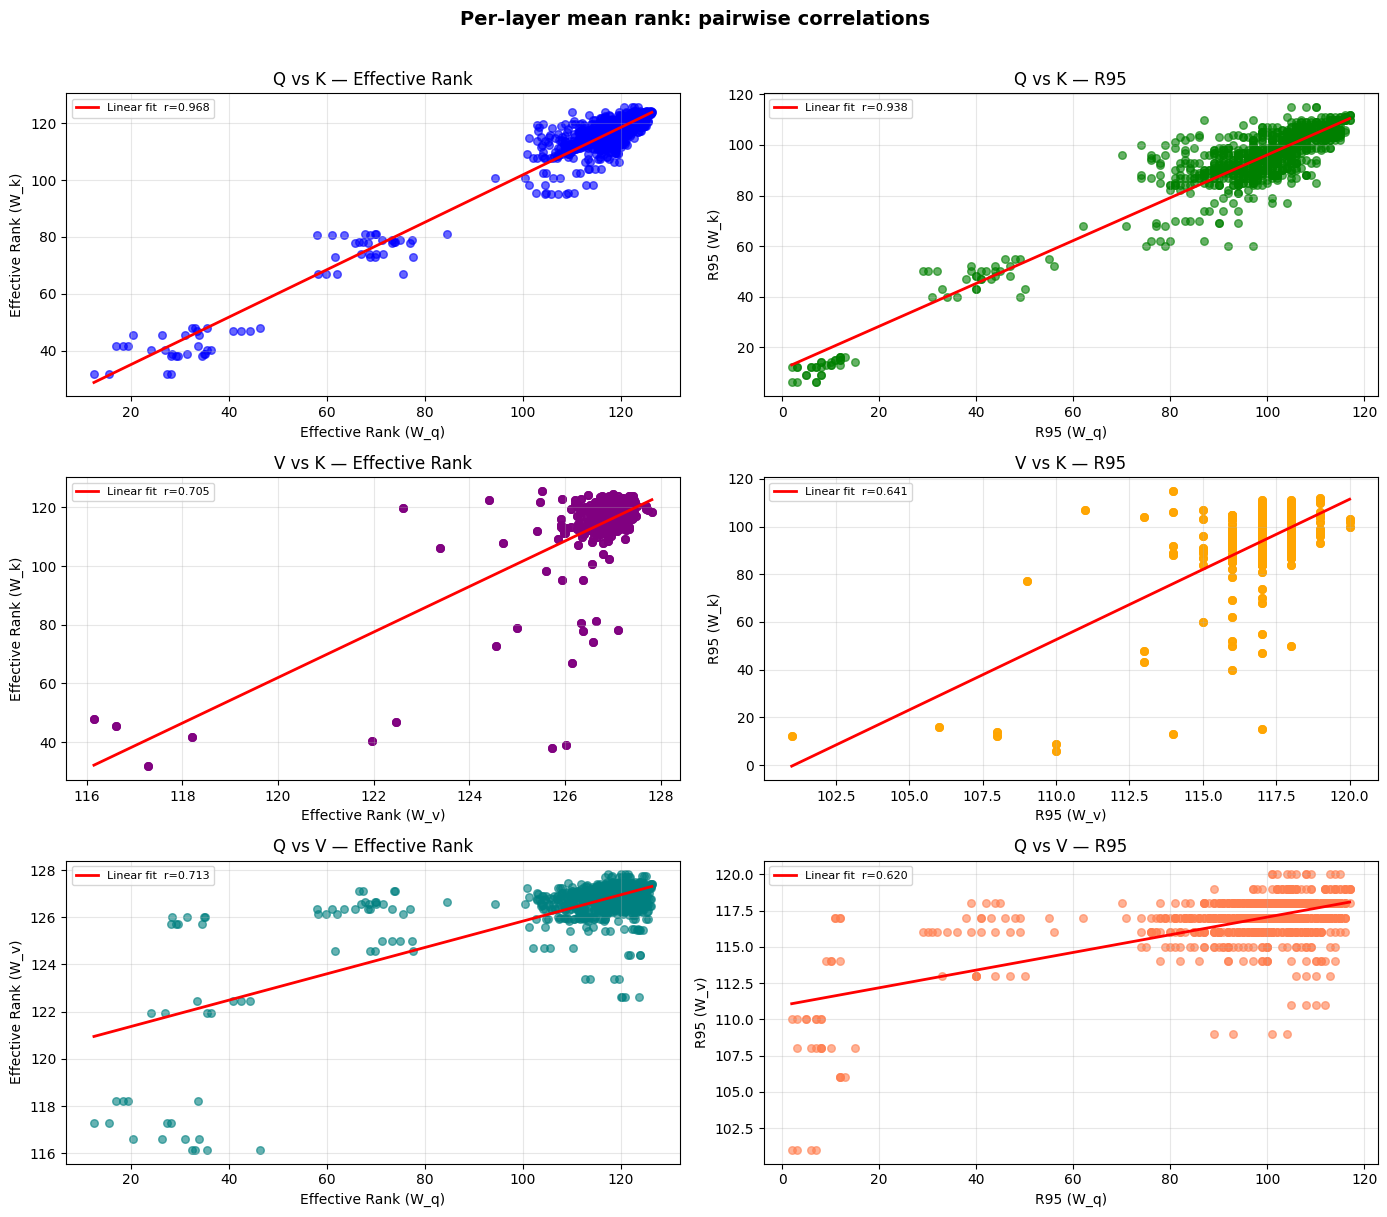

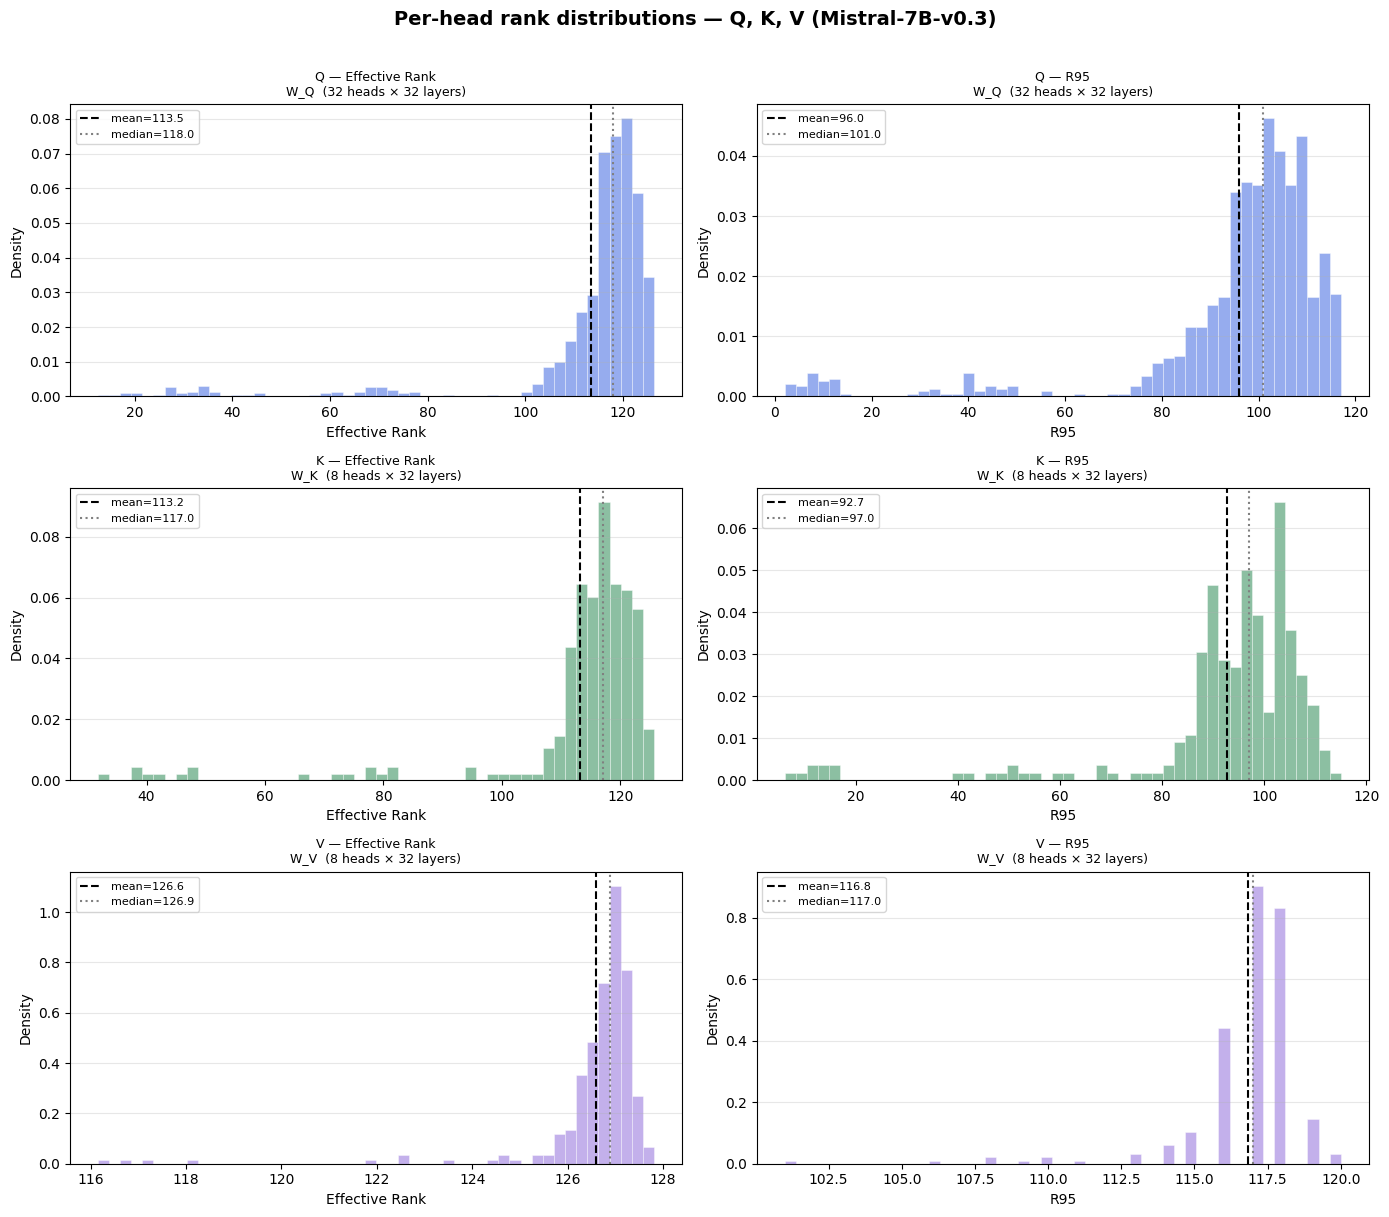

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# ── Pairing per-head con GQA (32 Q-heads, 8 KV-heads, ratio 4:1) ─────────────
# Per ogni layer: K-head 0 → Q-heads 0-3, K-head 1 → Q-heads 4-7, ecc.

records_paired = []

for layer in df2["layer"].unique():
    q_data = df2[(df2["layer"] == layer) & (df2["proj"] == "Q")].sort_values("head").reset_index(drop=True)
    k_data = df2[(df2["layer"] == layer) & (df2["proj"] == "K")].sort_values("head").reset_index(drop=True)
    v_data = df2[(df2["layer"] == layer) & (df2["proj"] == "V")].sort_values("head").reset_index(drop=True)

    n_q    = len(q_data)
    n_kv   = len(k_data)
    ratio  = n_q // n_kv  # = 4 per Mistral GQA

    for q_idx in range(n_q):
        kv_idx = q_idx // ratio  # quale KV-head corrisponde
        records_paired.append({
            "layer":   layer,
            "q_head":  q_idx,
            "kv_head": kv_idx,
            "erank_Q": q_data.loc[q_idx, "erank"],
            "erank_K": k_data.loc[kv_idx, "erank"],
            "erank_V": v_data.loc[kv_idx, "erank"],
            "r95_Q":   q_data.loc[q_idx, "r95"],
            "r95_K":   k_data.loc[kv_idx, "r95"],
            "r95_V":   v_data.loc[kv_idx, "r95"],
        })

paired = pd.DataFrame(records_paired)
print(f"Paired DataFrame: {paired.shape}  → attesi {32*32} = 1024 righe")

# Shorthand (ora sono Series con 1024 elementi)
q_er = paired["erank_Q"];  k_er = paired["erank_K"];  v_er = paired["erank_V"]
q_r  = paired["r95_Q"];    k_r  = paired["r95_K"];    v_r  = paired["r95_V"]

def scatter_fit(ax, x, y, color, xlabel, ylabel, title):
    mask = ~(np.isnan(x) | np.isnan(y))
    xc, yc = x[mask], y[mask]
    z = np.polyfit(xc, yc, 1)
    xl = np.linspace(xc.min(), xc.max(), 200)
    r, p = stats.pearsonr(xc, yc)
    ax.scatter(xc, yc, alpha=0.6, s=30, color=color)
    ax.plot(xl, np.poly1d(z)(xl), 'r-', lw=2, label=f'Linear fit  r={r:.3f}')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Scatter plots (3 coppie × 2 metriche)
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(3, 2, figsize=(14, 12))

scatter_fit(axes1[0,0], q_er, k_er, 'blue',   'Effective Rank (W_q)', 'Effective Rank (W_k)', 'Q vs K — Effective Rank')
scatter_fit(axes1[0,1], q_r,  k_r,  'green',  'R95 (W_q)',            'R95 (W_k)',            'Q vs K — R95')
scatter_fit(axes1[1,0], v_er, k_er, 'purple', 'Effective Rank (W_v)', 'Effective Rank (W_k)', 'V vs K — Effective Rank')
scatter_fit(axes1[1,1], v_r,  k_r,  'orange', 'R95 (W_v)',            'R95 (W_k)',            'V vs K — R95')
scatter_fit(axes1[2,0], q_er, v_er, 'teal',   'Effective Rank (W_q)', 'Effective Rank (W_v)', 'Q vs V — Effective Rank')
scatter_fit(axes1[2,1], q_r,  v_r,  'coral',  'R95 (W_q)',            'R95 (W_v)',            'Q vs V — R95')

fig1.suptitle('Per-layer mean rank: pairwise correlations', fontsize=14, fontweight='bold', y=1.01)
fig1.tight_layout()
fig1.savefig("scatterplots_rank.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Istogrammi separati Q / K / V con KDE overlay
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

proj_cfg = [
    ("Q", "royalblue",  "W_Q  (32 heads × 32 layers)"),
    ("K", "seagreen",   "W_K  (8 heads × 32 layers)"),
    ("V", "mediumpurple","W_V  (8 heads × 32 layers)"),
]

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 12), sharey=False)

for row, (proj, color, subtitle) in enumerate(proj_cfg):
    d = df2[df2["proj"] == proj]

    for col, (metric, xlabel) in enumerate([("erank", "Effective Rank"), ("r95", "R95")]):
        ax = axes2[row, col]
        vals = d[metric].dropna().values

        ax.hist(vals, bins=50, density=True, color=color, alpha=0.55, edgecolor='white', lw=0.5)

        '''# KDE overlay
        kde = gaussian_kde(vals, bw_method='scott')
        xs  = np.linspace(vals.min(), vals.max(), 400)
        ax.plot(xs, kde(xs), color=color, lw=2.5)'''

        # Linee verticali per media e mediana
        ax.axvline(np.mean(vals),   color='black', lw=1.5, ls='--', label=f'mean={np.mean(vals):.1f}')
        ax.axvline(np.median(vals), color='gray',  lw=1.5, ls=':',  label=f'median={np.median(vals):.1f}')

        ax.set_xlabel(xlabel)
        ax.set_ylabel('Density')
        ax.set_title(f'{proj} — {xlabel}\n{subtitle}', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

fig2.suptitle('Per-head rank distributions — Q, K, V (Mistral-7B-v0.3)', fontsize=14, fontweight='bold', y=1.01)
fig2.tight_layout()
fig2.savefig("histograms_rank_per_head.png", dpi=150, bbox_inches="tight")
plt.show()


KeyError: 'layer'